# batss CRN benchmarks

Each CRN below defines a `CRNSpec` (whose `benchmark_end_time` field sets the simulated end time for the runtime benchmark) plus a couple of per-CRN variables (`trajectory_n`, `trajectory_end_time`). To benchmark and plot a CRN:

1. Run its definition cell.
2. Run the **Run** cell at the bottom.

Runtime measurements are cached to JSON under `DATA_DIR`, so rerunning the **Run** cell skips already-computed `(backend, n)` pairs. Plots are also written there, to filenames derived from the `CRNSpec`.

In [1]:
import batss as bt
from batss.benchmarking import CRNSpec, benchmark_runtimes, plot_runtimes, plot_trajectory

DATA_DIR = "data"

## Dimerization

$M + M \rightleftharpoons D$, reversible with both rates 1.

In [2]:
m, d = bt.species("M D")
spec = CRNSpec(
    name="Dimerization",
    rxns=[
        (m + m >> d).k(1),
        (d >> m + m).k(1),
    ],
    inits_from_n=lambda n: {m: n},
    benchmark_end_time=0.5,
)
trajectory_n = 10**5
trajectory_end_time = 2.0
benchmark_pop_sizes = [10**e for e in range(3, 12)]

## Rössler-Willamowski

Three-species chaotic system. Thirds initial split.

In [4]:
x1, x2, x3 = bt.species("X1 X2 X3")
spec = CRNSpec(
    name="Rössler-Willamowski",
    rxns=[
        (x1 >> 2 * x1).k(30),
        (2 * x1 >> x1).k(0.5),
        (x2 + x1 >> 2 * x2).k(1),
        (x2 >> None).k(10),
        (x1 + x3 >> None).k(1),
        (x3 >> 2 * x3).k(16.5),
        (2 * x3 >> x3).k(0.5),
    ],
    inits_from_n=lambda n: {x1: n // 3, x2: n // 3, x3: n // 3},
    benchmark_end_time=1.0,
)
trajectory_n = 10**5
trajectory_end_time = 8.0
benchmark_pop_sizes = [10**e for e in range(3, 9)]

# Oregonator

Oregonator model of the Belousov–Zhabotinsky oscillatory reactions.

In [8]:
x1, x2, x3 = bt.species("X1 X2 X3")
# The two bimolecular rates are reduced from the textbook Oregonator values
# (1.6e9 and 4e7), which are calibrated for concentrations ~1e-7. Here the
# simulators use volume=n and the counts are ~n, i.e. concentration ~1, so the
# textbook rates make the X1+X2 and 2X1 annihilations ~1e6x too fast: X1 and X2
# are wiped out instantly and everything collapses to 0. 1000 and 40 bring the
# limit cycle into the count~n regime so it actually oscillates.
spec = CRNSpec(
    name="Oregonator",
    rxns = [
        (x2 >> x1).k(0.0871),
        (x2 + x1 >> None).k(1000),       # textbook: 1.6e9
        (x1 >> 2 * x1 + x3).k(520),
        (2 * x1 >> None).k(40),          # textbook: 4e7
        (x3 >> x2).k(443.324),
        (x3 >> None).k(2.676),
    ],
    # Initial condition placed on the limit cycle (quiescent phase, X1 at its
    # minimum) so the trajectory oscillates immediately with no startup transient.
    # These concentrations sum to ~0.54, not 1, which is why _batss_sim passes
    # volume=n explicitly -- otherwise batss normalizes the counts to sum to 1,
    # landing off the cycle. Equal thirds or 1:4:1 instead spiral in ~2 periods.
    inits_from_n = lambda n: {x1: int(0.0029 * n), x2: int(0.5358 * n), x3: int(0.0034 * n)},
    benchmark_end_time=1.0,
)
# With working rates the CRN actually oscillates (counts stay ~n), so batss does
# real work: n=1e6 takes ~100s. The period is ~0.7, so t=5 shows ~7 oscillations.
trajectory_n = 10**5
trajectory_end_time = 5.0
benchmark_pop_sizes = [10**e for e in range(3, 11)]

## Lotka–Volterra

$R + F \to 2F$, $R \to 2R$, $F \to \varnothing$, all at rate 1. Half-and-half initial split.

In [10]:
r, f = bt.species("R F")
spec = CRNSpec(
    name="Lotka Volterra",
    rxns=[
        (r + f >> 2 * f).k(1),
        (r >> 2 * r).k(1),
        (f >> None).k(1),
    ],
    inits_from_n=lambda n: {r: n // 2, f: n - n // 2},
    benchmark_end_time=1.0,
)
trajectory_n = 10**5
trajectory_end_time = 20.0
benchmark_pop_sizes = [10**e for e in range(3, 12)]

## Shrinking population (k0 must track n)

$A + A \to B + B$ at rate 1, with fast decays $A \to \varnothing$, $B \to \varnothing$ at rate 100. The decays shrink the population, while the crossover ($= 50v$) stays far above $2n$ the whole run, so the throughput-optimal $k_0 = \min(2n,\ \text{crossover}) = 2n$ tracks the *shrinking* $n$. Freezing $k_0$ at the crossover is ~7.5× slower here — the mirror image of Rössler, where $n$ explodes and a fixed crossover is nearly optimal.

In [6]:
a, b = bt.species("A B")
spec = CRNSpec(
    name="Shrinking",
    rxns=[
        (a >> None).k(100),
        (b >> None).k(100),
        (2 * a >> 2 * b).k(1),
    ],
    inits_from_n=lambda n: {a: n // 2, b: n - n // 2},
    benchmark_end_time=0.05,
)
trajectory_n = 10**6
trajectory_end_time = 0.05
benchmark_pop_sizes = [10**e for e in range(3, 11)]

## Order-3 example (multiple padded orders)

A synthetic order-3 CRN with one reaction per order 1/2/3 ($A\to 2D$ at rate 1; $A+B\to 3D$ at 10; $A+B+C\to 4D$ at 1; volume $= n$). It exercises the **general** multi-branch case $k_\mathrm{max}(k_0)=\max_a A_a/k_0^{\,o-a}$. At $n=10^6$ the adjusted-rate numerators are $A_1=2$ (the order-1 reaction's two filler K's add a $2!$ symmetry factor), $A_2=10^{-5}$, $A_3=10^{-12}$, giving two crossovers $x_{21}=A_1/A_2=2\times10^5$ and $x_{10}=A_2/A_3=10^7$. The optimal $k_0$ walks across branches as $n$ grows: $4n$ (order-1, $\delta=2$) → plateau at $x_{21}$ → $2n/3$ (order-2, $\delta=1$) → plateau at $x_{10}$. `crossover_k_count` reports only $x_{10}$ (it handles the $\delta=1$ branch), so `k_reset_target`'s `min(n/(o-3/2), crossover)` is the $\delta=1$ approximation for $o\ge 3$ — see `K0_SELECTION.md`.

In [8]:
a, b, c, d = bt.species("A B C D")
spec = CRNSpec(
    name="Order-3 example",
    rxns=[
        (a >> 2 * b).k(1),            # order 1  (delta = 2)
        (a + d >> 2 * c).k(10),       # order 2  (delta = 1)
        (a + b + c >> 4 * d).k(1),    # order 3  (delta = 0, the flat floor)
    ],
    inits_from_n=lambda n: {a: n // 3, b: n // 3, c: n - 2 * (n // 3)},
    benchmark_end_time=1.0,
)
trajectory_n = 10**6
trajectory_end_time = 2.0
benchmark_pop_sizes = [10**e for e in range(3, 11)]

## Order-3 equilibrium (reversible association)

Reversible association $2A \rightleftharpoons B$ (rates 2, 1) and $3A \rightleftharpoons C$ (rates 4, 1) — orders 2 and 3 forward, order 1 back. From all $A$ it relaxes to a coexistence equilibrium (at $n=10^6$: $A\approx 303\text{k}$, $B\approx 183\text{k}$, $C\approx 110\text{k}$) where all four reactions keep firing, so the active fraction settles at a steady $\approx 0.076$ instead of decaying to 0. Macroscopically static, but every reaction stays active.

In [ ]:
a, b, c = bt.species("A B C")
spec = CRNSpec(
    name="Order-3 association",
    rxns=[
        (2 * a >> b).k(2),        # order 2
        (b >> 2 * a).k(1),        # order 1
        (3 * a >> c).k(4),        # order 3
        (c >> 3 * a).k(1),        # order 1
    ],
    inits_from_n=lambda n: {a: n},
    benchmark_end_time=6.0,
)
trajectory_n = 10**6
trajectory_end_time = 6.0
benchmark_pop_sizes = [10**e for e in range(3, 11)]

## Order-3 oscillator (Brusselator)

The Brusselator — its autocatalytic step $2X+Y\to 3X$ is order 3. $A$ and $B$ are catalytic fuel (they appear on both sides, so $[A]=1$ and $[B]=3$ stay fixed and never deplete), giving a *sustained* limit cycle with $b = 3 > 1 + a^2$: $X$ and $Y$ oscillate indefinitely. All orders 1/2/3 fire, and the active fraction oscillates low ($\approx 0.003$–$0.04$ — inherent to $o=3$ with large fuel reservoirs) but never reaches 0.

In [14]:
a, b, x, y = bt.species("A B X Y")
spec = CRNSpec(
    name="Order-3 Brusselator",
    rxns=[
        (a >> a + x).k(1),          # order 1: A-catalyzed source of X   ([A] = 1)
        (2 * x + y >> 3 * x).k(1),  # order 3: autocatalysis
        (b + x >> b + y).k(1),      # order 2: B-catalyzed X -> Y         ([B] = 3)
        (x >> None).k(1),           # order 1: X decay
    ],
    inits_from_n=lambda n: {a: n, b: 3 * n, x: n, y: n},
    benchmark_end_time=40.0,
)
trajectory_n = 10**5
trajectory_end_time = 20.0
benchmark_pop_sizes = [10**e for e in range(3, 9)]

## Run

Runs benchmarks and produces both plots for whichever CRN cell above was run most recently.

running batss for Rössler-Willamowski at n=$10^{5}$


  0%|          | 0/8.0 [00:00<?, ? time simulated/s]

<Axes: title={'center': 'Rössler-Willamowski: batss, n=$10^{5}$'}, xlabel='time', ylabel='count'>

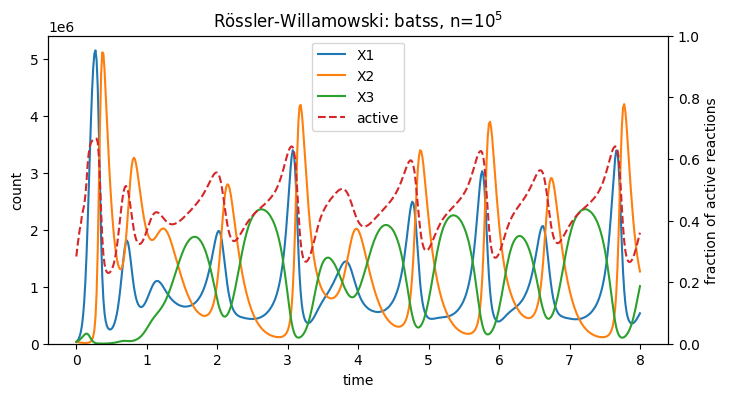

In [5]:
# benchmark_runtimes(
#     spec,
#     pop_sizes=benchmark_pop_sizes,
#     data_dir=DATA_DIR,
#     overwrite=True,
# )
# plot_runtimes(
#     spec,
#     data_dir=DATA_DIR,
# )
plot_trajectory(
    spec,
    n=trajectory_n,
    end_time=trajectory_end_time,
    data_dir=DATA_DIR,
    seed=1,
    num_samples=500,
    show_active=True,
    # heuristic=True,
    # backend='rebop',
    # loc="lower right",
)